<a href="https://colab.research.google.com/github/brianchinphd/SynPUFCostAnalysis/blob/main/PMPM_CT0809.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PMPM Trending and Attribution**

This project uses the publicly available synthetic Medicare data (2008-2010) retrieved from https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files/cms-2008-2010-data-entrepreneurs-synthetic-public-use-file-de-synpuf/de10-sample-13.

**Situation:** Provide cost-of-care teams with a clear trend signal to understand changes in spend and identify drivers for intervention.

**Problem:** Build a simple, reproducible framework to quantify PMPM trends by segment and test for coverage-duration mix distortion.

**Scope:** SynPUF data (2008–2010) for the Connecticut market with PMPM trends derived from member coverage and IP/OP/CAR spend.

# Executive Summary

**Objectives:** Calculate and contextualize the observed PMPM trend in the CT market from 2008–2009.

**Method:** Remove the truncated 2010 data and filter for a stable cohort of members with continuous 12-month coverage.

**Finding:** An observed –15.5% market trend masked a true +5.4% medical trend among stable members, driven by OP and Carrier spend.

# PMPM Calculations

In [3]:
# @title
# Import Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
ct08 = pd.read_csv('/content/DE1_0_2008_Beneficiary_Summary_File_Sample_13.csv',low_memory=False)
ct09 = pd.read_csv('/content/DE1_0_2009_Beneficiary_Summary_File_Sample_13.csv',low_memory=False)
ct10 = pd.read_csv('/content/DE1_0_2010_Beneficiary_Summary_File_Sample_13.csv',low_memory=False)

# Generate New Dataframe
# Combine and Filter for Connecticut (SP_STATE_CODE 07 is CT)

dfs = [ct08, ct09, ct10]
years = [2008, 2009, 2010]

combined_list = []
for df, yr in zip(dfs, years):
    df['YEAR'] = yr
    combined_list.append(df[df['SP_STATE_CODE'] == 7].copy())

ct_master = pd.concat(combined_list, ignore_index=True)

# Calculate the Total Payer Spend (Reimbursement across inpatient, outpatient, carrier)
ct_master['TOTAL_REIMB'] = (
    ct_master['MEDREIMB_IP'] +
    ct_master['MEDREIMB_OP'] +
    ct_master['MEDREIMB_CAR']
)

# PMPM Calculation (Annualized for the individual)
# Add line to avoid dividing by zero for members with 0 coverage months
ct_master['INDIV_PMPM'] = np.where(
    ct_master['PLAN_CVRG_MOS_NUM'] > 0,
    ct_master['TOTAL_REIMB'] / ct_master['PLAN_CVRG_MOS_NUM'],
    0
)

# Aggregate for Market Trend
pmpm_trend = ct_master.groupby('YEAR').agg({
    'TOTAL_REIMB': 'sum',
    'PLAN_CVRG_MOS_NUM': 'sum'
}).reset_index()

pmpm_trend['MARKET_PMPM'] = pmpm_trend['TOTAL_REIMB'] / pmpm_trend['PLAN_CVRG_MOS_NUM']

In [4]:
# @title
# Summarize the annual trends
print("--- CONNECTICUT MARKET PMPM TREND (2008-2010) ---")
print(pmpm_trend[['YEAR', 'TOTAL_REIMB', 'PLAN_CVRG_MOS_NUM', 'MARKET_PMPM']].to_string(index=False))

# Calculate % Change between 2008 and 2010
total_growth = (pmpm_trend.iloc[-1]['MARKET_PMPM'] / pmpm_trend.iloc[0]['MARKET_PMPM'] - 1) * 100
print(f"\nOverall 3-Year Trend: {total_growth:.2f}%")

--- CONNECTICUT MARKET PMPM TREND (2008-2010) ---
 YEAR  TOTAL_REIMB  PLAN_CVRG_MOS_NUM  MARKET_PMPM
 2008    5618130.0               8840   635.535068
 2009    6447580.0              12009   536.895662
 2010    3336380.0              12933   257.974175

Overall 3-Year Trend: -59.41%


Our Connecticut market analysis reveals a significant PMPM decrease from 635.54 USD in 2008 to 536.90 USD in 2009, representing a -15.5% year-over-year cost trend.

While member months increased from 2009 to 2010, the 2010 data shows an artificial 52% drop to $257.97, which likely indicates a data capture issue in the synthetic sample rather than a true shift in medical spend.

Thus, I decided to focus on examining the trends between 2008 and 2009. Because the number of coverage months increased by 35.8% in that period, it is possible that the decrease in PMPM was attributable to a healthier member mix.

# Member Mix Investigation (Age, Acuity, Coverage)

In [5]:
# @title
# 1. Calculate Age (Birth Date is YYYYMMDD)
ct_master['BENE_BIRTH_DT'] = pd.to_datetime(ct_master['BENE_BIRTH_DT'], format='%Y%m%d')
ct_master['AGE'] = ct_master['YEAR'] - ct_master['BENE_BIRTH_DT'].dt.year

# 2. Convert Chronic Conditions to binary (1 = Yes, 0 = No)
# Original coding: 1=Yes, 2=No
chronic_cols = [
    'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD',
    'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS',
    'SP_RA_OA', 'SP_STRKETIA'
]

for col in chronic_cols:
    ct_master[f'{col}_FLAG'] = np.where(ct_master[col] == 1, 1, 0)

# 3. Sum the flags for an 'Acuity Score'
ct_master['CHRONIC_COUNT'] = ct_master[[f'{c}_FLAG' for c in chronic_cols]].sum(axis=1)

# 4. Final Aggregation by Year
acuity_results = ct_master.groupby('YEAR').agg({
    'AGE': 'mean',
    'CHRONIC_COUNT': 'mean',
    'DESYNPUF_ID': 'count'
}).rename(columns={'DESYNPUF_ID': 'Member_Count'})

print("--- CT MARKET ACUITY VERIFICATION ---")
print(acuity_results.round(2))

--- CT MARKET ACUITY VERIFICATION ---
        AGE  CHRONIC_COUNT  Member_Count
YEAR                                    
2008  72.97           2.15          1480
2009  73.93           2.57          1456
2010  74.95           1.80          1430


We observe an increase in average age from 72.9 to 73.9 and an increase in average chronic condition count from 2.2 to 2.6 per member. The population got older and had higher acuity.

Next, I wanted to check whether the average coverage differed between 2008 and 2009.

In [6]:
# @title
# Calculate Average Months per Member
acuity_results['AVG_MONTHS_PER_MEMBER'] = (
    pmpm_trend.set_index('YEAR')['PLAN_CVRG_MOS_NUM'] / acuity_results['Member_Count']
)

print("--- COVERAGE DURATION ANALYSIS ---")
print(acuity_results[['Member_Count', 'AVG_MONTHS_PER_MEMBER']].round(2))

--- COVERAGE DURATION ANALYSIS ---
      Member_Count  AVG_MONTHS_PER_MEMBER
YEAR                                     
2008          1480                   5.97
2009          1456                   8.25
2010          1430                   9.04


Average coverage duration increased from 5.97 to 8.25 months between 2008–2009. This pattern is consistent with a coverage-duration mix shift that can deflate the aggregate PMPM.

Because the aggregate PMPM trend was unexpected, I used population segmentation to examine this trend among only the members who reported stable 12 months of coverage.

# Segmentation by Coverage Duration

In [7]:
# @title
# Flag the 'Full Year' members
full_year_members = ct_master[ct_master['PLAN_CVRG_MOS_NUM'] == 12]

# Calculate PMPM for just this group
stable_trend = full_year_members.groupby('YEAR').agg({
    'TOTAL_REIMB': 'mean', # Since months = 12, Mean Reimbursement / 12 = PMPM
    'DESYNPUF_ID': 'count'
}).reset_index()

stable_trend['STABLE_PMPM'] = stable_trend['TOTAL_REIMB'] / 12

print("--- FULL YEAR COHORT ANALYSIS (12-Month Members Only) ---")
print(stable_trend[['YEAR', 'STABLE_PMPM', 'DESYNPUF_ID']])

--- FULL YEAR COHORT ANALYSIS (12-Month Members Only) ---
   YEAR  STABLE_PMPM  DESYNPUF_ID
0  2008   396.360867          684
1  2009   417.744887          929
2  2010   225.102891          980


Segmentation by coverage duration reveals a more intuitive increase of 5.4% in PMPM costs from 396.36 to 417.74 USD, and an increase in members with full-year coverage from 684 to 929.

While the population acuity increased from 2008–2009, the underlying cost drivers remained consistent with standard Medicare growth projections. The 2010 data remains excluded due to evident truncation.

In [8]:
# @title
#Summarize the PMPM segmentation findings
data = {
    'Metric': ['Raw Market PMPM', 'Stable Cohort PMPM', 'Mix Distortion Effect'],
    '2008': [635.54, 396.36, None],
    '2009': [536.90, 417.74, None],
    '% Change': ['-15.5%', '+5.4%', '-20.9%']
}

decomposition_df = pd.DataFrame(data)

print("--- 2008-2009 PMPM DECOMPOSITION BY SEGMENT ---")
print(decomposition_df.to_string(index=False, na_rep='—'))

--- 2008-2009 PMPM DECOMPOSITION BY SEGMENT ---
               Metric   2008   2009 % Change
      Raw Market PMPM 635.54 536.90   -15.5%
   Stable Cohort PMPM 396.36 417.74    +5.4%
Mix Distortion Effect      —      —   -20.9%


The observed shift toward longer coverage duration is consistent with a mix distortion that can produce apparent PMPM decreases.

This masked an underlying +5.4% medical cost trend among members who were covered for the full year.

# Visualize the Findings

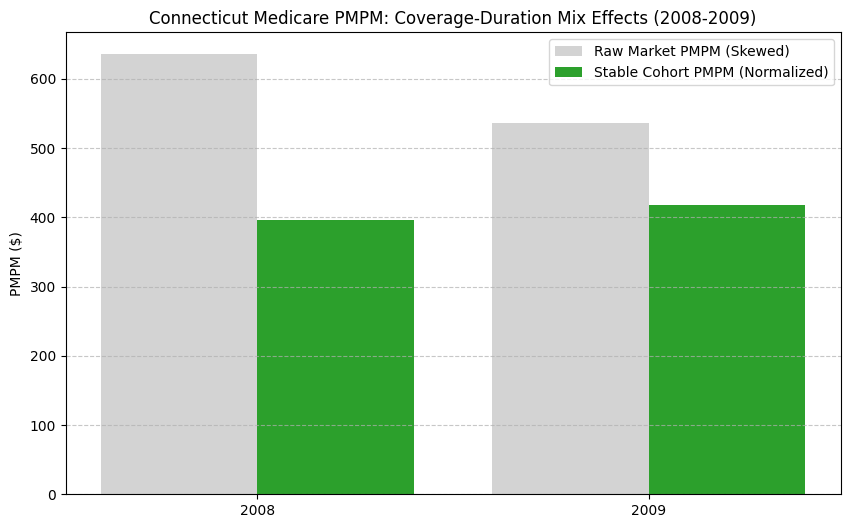

In [9]:
# @title
# Visualize the PMPM trend by segment
years = ['2008', '2009']
raw_pmpm = [635.54, 536.90]
stable_pmpm = [396.36, 417.74]

x = range(len(years))

plt.figure(figsize=(10, 6))
plt.bar(x, raw_pmpm, width=0.4, label='Raw Market PMPM (Skewed)', color='lightgray')
plt.bar([i + 0.4 for i in x], stable_pmpm, width=0.4, label='Stable Cohort PMPM (Normalized)', color='#2ca02c')

plt.xticks([i + 0.2 for i in x], years)
plt.ylabel('PMPM ($)')
plt.title('Connecticut Medicare PMPM: Coverage-Duration Mix Effects (2008-2009)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Decompose by Service Type

Finally, I wanted to decompose the PMPM by service type (IP/OP/CAR).

In [11]:
# @title
#Calculate Service-Level Means for the Stable Cohort (Full Year Members)
service_cols = ['MEDREIMB_IP', 'MEDREIMB_OP', 'MEDREIMB_CAR']
service_breakdown = full_year_members.groupby('YEAR')[service_cols].mean() / 12

#Build the Final Table
data = {
    'Metric': [
        'Raw Market PMPM',
        'Stable Cohort PMPM',
        '-- IP Contribution',
        '-- OP Contribution',
        '-- CAR Contribution',
        'Mix Distortion Effect'
    ],
    '2008': [
        635.54, 396.36,
        service_breakdown.loc[2008, 'MEDREIMB_IP'],
        service_breakdown.loc[2008, 'MEDREIMB_OP'],
        service_breakdown.loc[2008, 'MEDREIMB_CAR'],
        '—'
    ],
    '2009': [
        536.90, 417.74,
        service_breakdown.loc[2009, 'MEDREIMB_IP'],
        service_breakdown.loc[2009, 'MEDREIMB_OP'],
        service_breakdown.loc[2009, 'MEDREIMB_CAR'],
        '—'
    ],
    '% Change': ['-15.5%', '+5.4%', '–2.8%', '+14.5%', '+17.1%', '-20.9%']
}

final_df = pd.DataFrame(data)

print("--- FINAL CONNECTICUT CLAIMS AUDIT (2008-2009) ---")
print(final_df.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else x))

--- FINAL CONNECTICUT CLAIMS AUDIT (2008-2009) ---
               Metric   2008   2009 % Change
      Raw Market PMPM 635.54 536.90   -15.5%
   Stable Cohort PMPM 396.36 417.74    +5.4%
   -- IP Contribution 224.28 217.99    –2.8%
   -- OP Contribution  65.56  75.04   +14.5%
  -- CAR Contribution 106.53 124.72   +17.1%
Mix Distortion Effect      —      —   -20.9%


Within the full-year cohort, PMPM increased +5.4%, with the largest service-level increases observed in Outpatient and Carrier components.

# Methodology & Data Limitations

**2010 Data:** The 2010 data was excluded from the trend narrative due to evident claims truncation and an implausible PMPM of 257.97 USD for a population with an average age of 75 indicating incomplete reporting in the synthetic source file.

**Denominators:** Initial PMPM decreases were identified as a coverage-month mix shift. As average tenure increased from 6.0 to 8.2 months, denominator composition changed, which can alter aggregate PMPM interpretation.

**Synthetic Data:** Findings are derived from synthetic Medicare data and intended to demonstrate analytical logic and Payer-industry workflow rather than actual 2008-2010 Connecticut market conditions.